# Assignment 7 — Neural Network Bike-Sharing Demand Prediction


**Goal**: Use a simple fully connected neural network for predicting the number of rental bikes (`cnt`), and tune the neural network to find a better-performing model.

## 1. Imports library


In [36]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model


## 2. Load the bike-sharing dataset


In [10]:
# Define the URL from which to fetch the CSV data.
url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_2_regression_model/Exercise2BikeSharing.csv'

# Use pandas to read the CSV data from the specified URL and store it in a DataFrame 'df'.
df = pd.read_csv(url)
# Display the first 10 rows of the DataFrame 'df'.
df.head(10)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


In [11]:
# shape
print("Shape:", df.shape)

Shape: (17379, 17)


## 3. Initial data inspection - NaN


In [12]:
display(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.3 MB


None

## 4. Define the prediction problem and features

### Target

- `cnt` = total number of rental bikes.

### Predictors

- Weather: `temp`, `atemp`, `hum`, `windspeed`, `weathersit`
- Calendar/time: `hr`, `weekday`, `workingday`, `holiday`, `season`
- Year: `yr`


In [13]:
TARGET = "cnt"

FEATURES = [
    "temp", "atemp", "hum", "windspeed", "weathersit",
    "hr", "weekday", "workingday", "holiday", "season", "yr"
]

X = df[FEATURES].copy()
y = df[TARGET].astype(float)

print("Number of input features:", X.shape[1])
print("Features:", FEATURES)
print("Target:", TARGET)


Number of input features: 11
Features: ['temp', 'atemp', 'hum', 'windspeed', 'weathersit', 'hr', 'weekday', 'workingday', 'holiday', 'season', 'yr']
Target: cnt


## 5. Explore


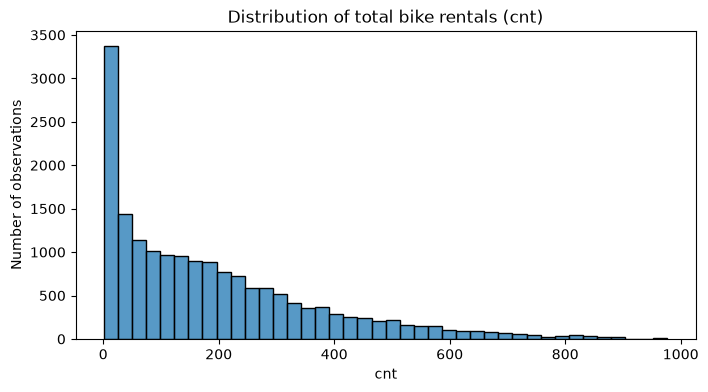

Correlation with target:


,correlation_with_cnt
cnt,1.000000
temp,0.404772
atemp,0.400929
hr,0.394071
yr,0.250495
season,0.178056
windspeed,0.093234
workingday,0.030284
weekday,0.026900
holiday,-0.030927


In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(y, bins=40, ax=ax)
ax.set_title("Distribution of total bike rentals (cnt)")
ax.set_xlabel("cnt")
ax.set_ylabel("Number of observations")
plt.show()

print("Correlation with target:")
corr = df[FEATURES + [TARGET]].corr(numeric_only=True)[TARGET].sort_values(ascending=False)
display(corr.to_frame("correlation_with_cnt"))


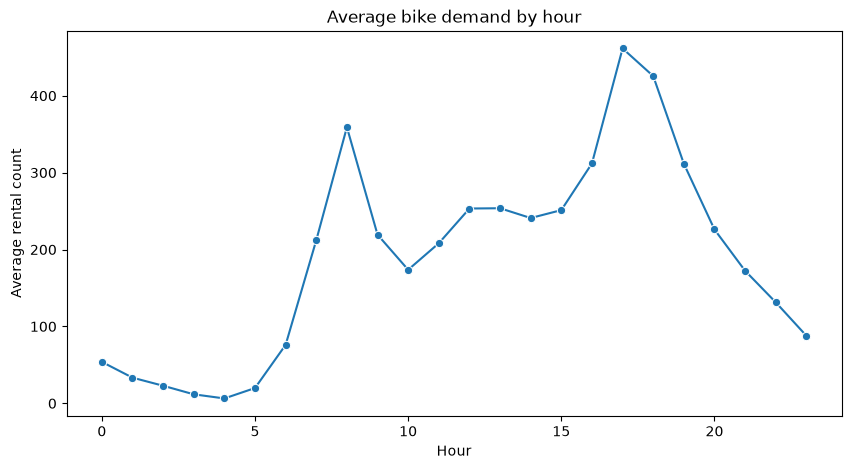

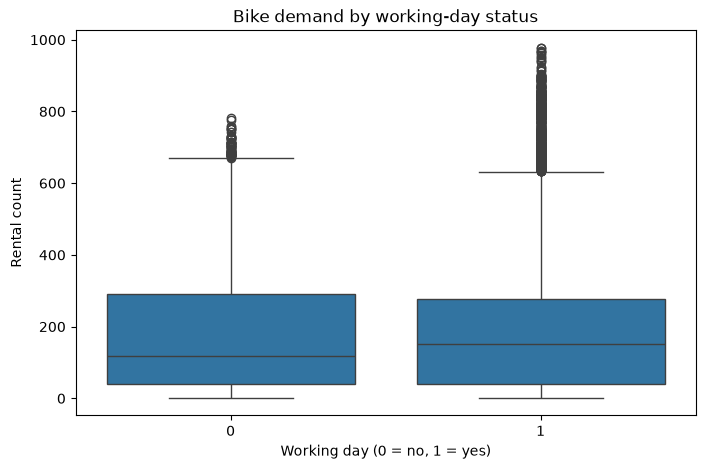

In [15]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df.groupby("hr", as_index=False)["cnt"].mean(), x="hr", y="cnt", marker="o")
plt.title("Average bike demand by hour")
plt.xlabel("Hour")
plt.ylabel("Average rental count")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="workingday", y="cnt")
plt.title("Bike demand by working-day status")
plt.xlabel("Working day (0 = no, 1 = yes)")
plt.ylabel("Rental count")
plt.show()


## 6. Train/test split


In [16]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev, test_size=0.20, random_state=42
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Final test:", X_test.shape)


Training: (11122, 11)
Validation: (2781, 11)
Final test: (3476, 11)


## 7. Scale the input features


In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)


Scaled training shape: (11122, 11)


## 8. Create baseline neural network


In [18]:
# same as class but build a function code where numbers can be changes easily for the tuning

# create Suquential model 
def build_nn(hidden_layers=(32, 64), dropout_rate=0.0, learning_rate=0.001):
    model = Sequential()
    model.add(Input(shape=(X_train_scaled.shape[1],)))

    for units in hidden_layers:
        # add dense layer, with ReLU activation, and a drop out rate
        model.add(Dense(units, activation="relu"))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(1))


    # compile the model with Ada optimizer, MAE loss fucntion and MAE metric 
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="mae",
        metrics=["mae"]
    )
    return model

baseline_model = build_nn(
    hidden_layers=(32, 64),
    dropout_rate=0.0,
    learning_rate=0.001
)

baseline_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,561 (10.00 KB)

 Trainable params: 2,561 (10.00 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Train the baseline model

- **EarlyStopping:** stops training when validation MAE stops improving and restores the best weights.
- **ReduceLROnPlateau:** reduces the learning rate when validation performance stops improving.
- **ModelCheckpoint:** saves the best model according to validation MAE.


In [19]:
BASELINE_PATH = "baseline_best.keras"

baseline_checkpoint = ModelCheckpoint(
    BASELINE_PATH,
    monitor="val_mae",
    mode="min",
    save_best_only=True,
    verbose=0
)

baseline_early_stop = EarlyStopping(
    monitor="val_mae",
    mode="min",
    patience=10,
    restore_best_weights=True
)

baseline_reduce_lr = ReduceLROnPlateau(
    monitor="val_mae",
    mode="min",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=0
)

history_baseline = baseline_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[
        baseline_checkpoint,
        baseline_early_stop,
        baseline_reduce_lr
    ],
    verbose=0
)

print("Epochs actually used:", len(history_baseline.history["loss"]))


Epochs actually used: 200


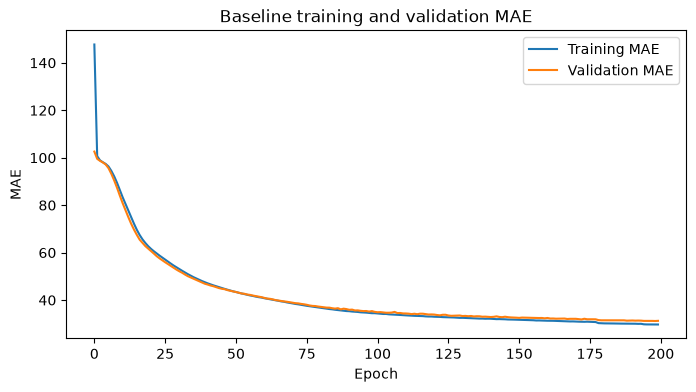

In [21]:
def plot_history(history, title):
    plt.figure(figsize=(8, 4))
    plt.plot(history.history["mae"], label="Training MAE")
    plt.plot(history.history["val_mae"], label="Validation MAE")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.title(title)
    plt.legend()
    plt.show()

plot_history(history_baseline, "Baseline training and validation MAE")


nice, perfeclty match, no overfitting

## 10. Evaluation function

In [22]:
def regression_metrics(y_true, y_pred):
    y_pred = np.asarray(y_pred).reshape(-1)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

baseline_val_pred = baseline_model.predict(X_val_scaled, verbose=0)
baseline_test_pred = baseline_model.predict(X_test_scaled, verbose=0)

print("Baseline validation:")
display(pd.DataFrame([regression_metrics(y_val, baseline_val_pred)]))

print("Baseline test:")
display(pd.DataFrame([regression_metrics(y_test, baseline_test_pred)]))


Baseline validation:


,MAE,RMSE,R2
0,31.191654,49.17004,0.92584


Baseline test:


,MAE,RMSE,R2
0,30.482775,49.316737,0.923193


# 11. Tune neural network manually


In [23]:
from itertools import product

# selected network sizes 
architectures = [
    (32, 64),
    (64, 64),
    (64, 128, 64),
    (128, 64)
]

# selected dropouts and learning rates
dropout_rates = [0.0, 0.2, 0.4]
learning_rates = [0.001, 0.0005]

search_results = []

for hidden_layers, dropout_rate, learning_rate in product(
    architectures, dropout_rates, learning_rates
):
    model = build_nn(
        hidden_layers=hidden_layers,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate
    )

    temp_path = "tuning_best.keras"

    checkpoint = ModelCheckpoint(
        temp_path,
        monitor="val_mae",
        mode="min",
        save_best_only=True,
        verbose=0
    )

    early_stop = EarlyStopping(
        monitor="val_mae",
        mode="min",
        patience=10,
        restore_best_weights=True
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_mae",
        mode="min",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=0
    )

    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=200,
        batch_size=32,
        callbacks=[checkpoint, early_stop, reduce_lr],
        verbose=0
    )

    best_val_mae = min(history.history["val_mae"])
    best_epoch = int(np.argmin(history.history["val_mae"]) + 1)

    val_pred = model.predict(X_val_scaled, verbose=0)
    metrics = regression_metrics(y_val, val_pred)

    search_results.append({
        "hidden_layers": str(hidden_layers),
        "dropout": dropout_rate,
        "learning_rate": learning_rate,
        "best_epoch": best_epoch,
        "val_MAE": metrics["MAE"],
        "val_RMSE": metrics["RMSE"],
        "val_R2": metrics["R2"]
    })

search_results_df = pd.DataFrame(search_results).sort_values("val_MAE").reset_index(drop=True)

print("Top neural-network configurations:")
display(search_results_df.head(10))


Top neural-network configurations:


,hidden_layers,dropout,learning_rate,best_epoch,val_MAE,val_RMSE,val_R2
0,"(64, 128, 64)",0.0,0.0010,196,26.814045,43.952293,0.940744
1,"(64, 128, 64)",0.0,0.0005,198,27.582522,44.898155,0.938166
2,"(128, 64)",0.0,0.0010,200,29.419950,46.946009,0.932397
3,"(64, 64)",0.0,0.0010,200,30.042729,47.697477,0.930215
4,"(128, 64)",0.0,0.0005,197,30.408188,48.303701,0.928430
5,"(64, 128, 64)",0.2,0.0005,111,31.867272,50.013698,0.923273
6,"(64, 128, 64)",0.2,0.0010,96,33.213014,52.452281,0.915609
7,"(32, 64)",0.0,0.0005,200,33.820517,53.930421,0.910785
8,"(64, 64)",0.0,0.0005,200,35.521468,58.740951,0.894160
9,"(32, 64)",0.0,0.0010,200,36.463337,60.269536,0.888579


the larger the network size the the lower the MAE values. dropout does not help. but it stops almost all the time as 200 epoch, maybe test higher?

In [24]:
# Test the best configuration from the previous tuning search

best_model_long = build_nn(
    hidden_layers=(64, 128, 64),
    dropout_rate=0.0,
    learning_rate=0.001
)

early_stop_long = EarlyStopping(
    monitor="val_mae",
    mode="min",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# Reduce the learning rate when validation MAE stops improving.
reduce_lr_long = ReduceLROnPlateau(
    monitor="val_mae",
    mode="min",
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

# Train the model for up to 300 epochs.
history_long = best_model_long.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=300, # change for test
    batch_size=32,
    callbacks=[early_stop_long, reduce_lr_long],
    verbose=1
)

# Find the epoch with the lowest validation MAE.
best_epoch_long = int(
    np.argmin(history_long.history["val_mae"]) + 1
)

# Get the lowest validation MAE.
best_val_mae_long = min(
    history_long.history["val_mae"]
)

print("Best epoch:", best_epoch_long)
print("Best validation MAE:", best_val_mae_long)

Epoch 1/300
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 641us/step - loss: 115.9570 - mae: 115.9570 - val_loss: 98.9249 - val_mae: 98.9249 - learning_rate: 0.0010
Epoch 2/300
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 446us/step - loss: 96.4679 - mae: 96.4679 - val_loss: 92.0097 - val_mae: 92.0097 - learning_rate: 0.0010
Epoch 3/300
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 446us/step - loss: 87.2638 - mae: 87.2638 - val_loss: 81.3692 - val_mae: 81.3692 - learning_rate: 0.0010
Epoch 4/300
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 426us/step - loss: 77.3751 - mae: 77.3751 - val_loss: 72.0109 - val_mae: 72.0109 - learning_rate: 0.0010
Epoch 5/300
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 423us/step - loss: 69.5878 - mae: 69.5878 - val_loss: 66.6918 - val_mae: 66.6918 - learning_rate: 0.0010
Epoch 6/300
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 423us/step - loss: 64.4427 - mae: 64.4427 - val_loss: 63.0126 - val_mae: 63.0126 - learning_rate: 0.0010
Epoch 7/300
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 421us/step - loss: 61.5551 - mae: 61.5551 - val_loss: 60.103

In [35]:
# Predict the validation data using new best

val_pred_long = best_model_long.predict(
    X_val_scaled,
    verbose=0
)

# Calculate validation performance.
long_metrics = regression_metrics(
    y_val,
    val_pred_long
)

print("Validation performance of the longer-trained model:")
print(f"MAE:  {long_metrics['MAE']:.3f}")
print(f"RMSE: {long_metrics['RMSE']:.3f}")
print(f"R²:   {long_metrics['R2']:.3f}")

Validation performance of the longer-trained model:
MAE:  25.946
RMSE: 42.482
R²:   0.945


In [26]:
best_config = search_results_df.iloc[0]

print("Best validation configuration:")
print(best_config)


Best validation configuration:
hidden_layers    (64, 128, 64)
dropout                    0.0
learning_rate            0.001
best_epoch                 196
val_MAE              26.814045
val_RMSE             43.952293
val_R2                0.940744
Name: 0, dtype: object


# 12. Retrain the selected architecture

Train the selected model on the entire development dataset (80% of the original data).

In [27]:
# Refit the scaler using ALL development data.

final_scaler = StandardScaler()

X_dev_scaled = final_scaler.fit_transform(X_dev)

# Apply the same scaler to the untouched final test data.
X_test_final_scaled = final_scaler.transform(X_test)

print("Development data:", X_dev_scaled.shape)
print("Final test data:", X_test_final_scaled.shape)

Development data: (13903, 11)
Final test data: (3476, 11)


In [28]:
# Create the final neural network using the best 

best_architecture = (64, 128, 64)
best_dropout = 0.0
best_learning_rate = 0.001

final_model = build_nn(
    hidden_layers=best_architecture,
    dropout_rate=best_dropout,
    learning_rate=best_learning_rate
)

# Train the final model on ALL development data.

history_final = final_model.fit(
    X_dev_scaled,
    y_dev,
    epochs=214,
    batch_size=32,
    verbose=1
)

print("Final model trained.")
print("Architecture:", best_architecture)
print("Dropout:", best_dropout)
print("Learning rate:", best_learning_rate)
print("Epochs:", 214)

Epoch 1/214
435/435 ━━━━━━━━━━━━━━━━━━━━ 1s 339us/step - loss: 113.2797 - mae: 113.2797
Epoch 2/214
435/435 ━━━━━━━━━━━━━━━━━━━━ 0s 325us/step - loss: 92.5722 - mae: 92.5722
Epoch 3/214
435/435 ━━━━━━━━━━━━━━━━━━━━ 0s 318us/step - loss: 81.7265 - mae: 81.7265
Epoch 4/214
435/435 ━━━━━━━━━━━━━━━━━━━━ 0s 322us/step - loss: 74.4128 - mae: 74.4128
Epoch 5/214
435/435 ━━━━━━━━━━━━━━━━━━━━ 0s 320us/step - loss: 69.0294 - mae: 69.0294
Epoch 6/214
435/435 ━━━━━━━━━━━━━━━━━━━━ 0s 320us/step - loss: 64.5307 - mae: 64.5307
Epoch 7/214
435/435 ━━━━━━━━━━━━━━━━━━━━ 0s 391us/step - loss: 61.1218 - mae: 61.1218
Epoch 8/214
435/435 ━━━━━━━━━━━━━━━━━━━━ 0s 368us/step - loss: 58.2931 - mae: 58.2931
Epoch 9/214
435/435 ━━━━━━━━━━━━━━━━━━━━ 0s 326us/step - loss: 55.5582 - mae: 55.5582
Epoch 10/214
435/435 ━━━━━━━━━━━━━━━━━━━━ 0s 322us/step - loss: 52.7025 - mae: 52.7025
Epoch 11/214
435/435 ━━━━━━━━━━━━━━━━━━━━ 0s 344us/step - loss: 49.8644 - mae: 49.8644
Epoch 12/214
435/435 ━━━━━━━━━━━━━━━━━━━━ 0s 329us

# 13. Final test-set evaluation

Now we finally evaluate the selected model on the **20% test set that was not used for tuning or model selection**.

These are the numbers that should be reported as the testing performance in the discussion post.


In [29]:
# Predict bike demand for the untouched final test set.

final_test_pred = final_model.predict(
    X_test_final_scaled,
    verbose=0
)

# Calculate the final test metrics.

final_test_metrics = regression_metrics(
    y_test,
    final_test_pred
)

print("FINAL SELECTED NEURAL NETWORK — TEST PERFORMANCE")

for metric, value in final_test_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nBest model parameters")
print("Hidden layers:", best_architecture)
print("Dropout:", best_dropout)
print("Learning rate:", best_learning_rate)
print("Batch size: 32")
print("Epochs:", 214)
print("Loss: MAE")


FINAL SELECTED NEURAL NETWORK — TEST PERFORMANCE
MAE: 25.6567
RMSE: 42.7862
R2: 0.9422

Best model parameters
Hidden layers: (64, 128, 64)
Dropout: 0.0
Learning rate: 0.001
Batch size: 32
Epochs: 214
Loss: MAE


## 14. Actual vs predicted values

A numerical metric tells us how large the errors are, but a plot helps us see whether predictions generally follow the actual values.

For a good regression model, points should be reasonably close to the diagonal line.


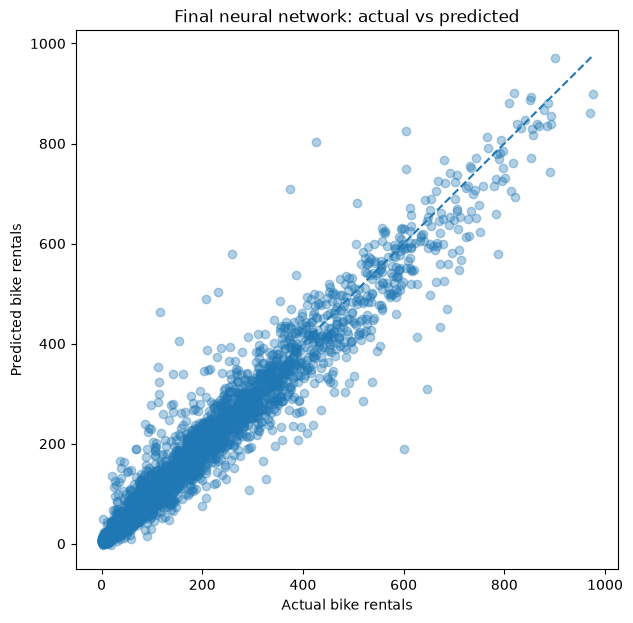

In [30]:
y_test_array = np.asarray(y_test)
pred_array = np.asarray(final_test_pred).reshape(-1)

plt.figure(figsize=(7, 7))
plt.scatter(y_test_array, pred_array, alpha=0.35)

lower = min(y_test_array.min(), pred_array.min())
upper = max(y_test_array.max(), pred_array.max())

plt.plot([lower, upper], [lower, upper], linestyle="--")
plt.xlabel("Actual bike rentals")
plt.ylabel("Predicted bike rentals")
plt.title("Final neural network: actual vs predicted")
plt.show()


## 15. Compare the neural network with the linear-regression baseline

The class exercise compares the neural network with linear regression.

The comparison is useful because linear regression is a much simpler model. If the neural network performs better, its nonlinear structure may be capturing relationships that the linear model cannot represent.

If the neural network does **not** perform better, that is also a useful finding: a more complicated model is not automatically a better model.


,Model,MAE,RMSE,R2
0,Linear Regression,104.795771,139.209601,0.387997
1,Selected Neural Network,25.656736,42.786203,0.942187


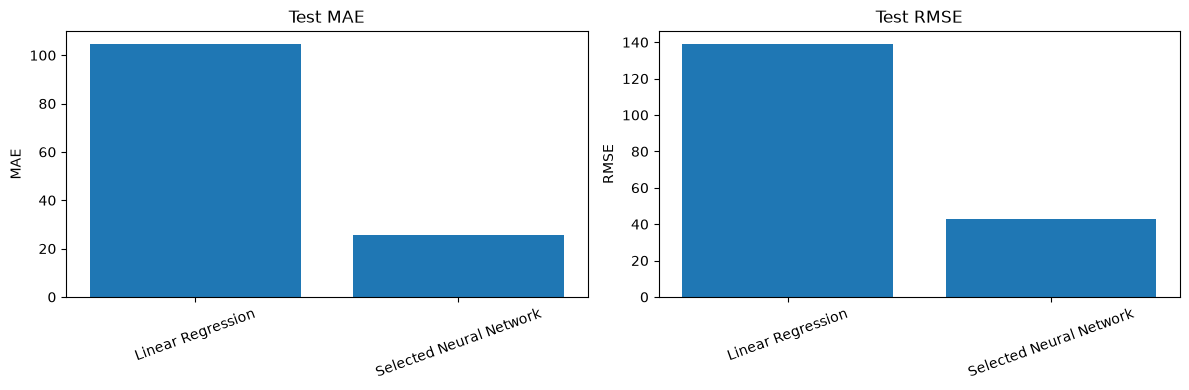

In [31]:
# Refit the linear baseline on the complete development set.
lr_final = LinearRegression()
lr_final.fit(X_dev_scaled, y_dev)

lr_test_pred = lr_final.predict(X_test_final_scaled)
lr_test_metrics = regression_metrics(y_test, lr_test_pred)

comparison = pd.DataFrame([
    {"Model": "Linear Regression", **lr_test_metrics},
    {"Model": "Selected Neural Network", **final_test_metrics}
])

display(comparison)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(comparison["Model"], comparison["MAE"])
axes[0].set_title("Test MAE")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(comparison["Model"], comparison["RMSE"])
axes[1].set_title("Test RMSE")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


# 17. Inspect overfitting


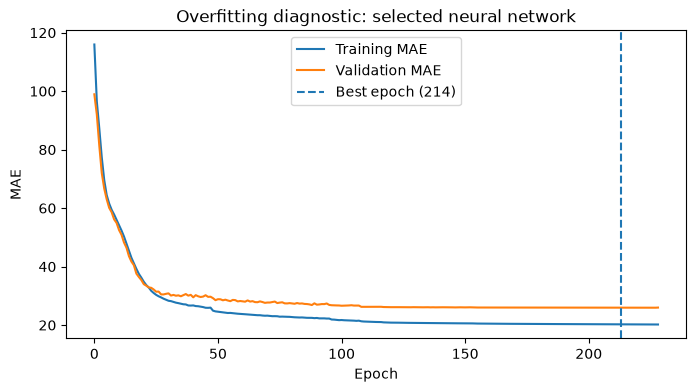

In [33]:

plt.figure(figsize=(8, 4))

plt.plot(
    history_long.history["mae"],
    label="Training MAE"
)

plt.plot(
    history_long.history["val_mae"],
    label="Validation MAE"
)

# Mark the best validation epoch.
plt.axvline(
    best_epoch_long - 1,
    linestyle="--",
    label=f"Best epoch ({best_epoch_long})"
)

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Overfitting diagnostic: selected neural network")
plt.legend()

plt.show()


# 18. Save and load the final model


In [34]:
FINAL_MODEL_PATH = "best_bike_sharing_nn.keras"

final_model.save(FINAL_MODEL_PATH)

print("Final model saved to:", FINAL_MODEL_PATH)

loaded_model = load_model(FINAL_MODEL_PATH)

loaded_pred = loaded_model.predict(X_test_final_scaled, verbose=0)
loaded_metrics = regression_metrics(y_test, loaded_pred)

print("Metrics from loaded model:")
for metric, value in loaded_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nModel file exists:", os.path.exists(FINAL_MODEL_PATH))
print("Model file:", FINAL_MODEL_PATH)


Final model saved to: best_bike_sharing_nn.keras
Metrics from loaded model:
MAE: 25.6567
RMSE: 42.7862
R2: 0.9422

Model file exists: True
Model file: best_bike_sharing_nn.keras
